# Tuning des hyperparamètres

Utiliser GridSearch et Optuna pour optimiser les hyperparamètres des meilleurs modèles identifiés dans les notebooks précédents. Documenter l'impact de chaque paramètre.

## Définition

Un hyperparamètre est un paramètre qu'on fixe avant l'entraînement et qui contrôle le comportement du modèle comme par exemple le nombre de voisins dans le LOF, le taux de contamination dans l'Isolation Forest, ou le nombre de couches dans un Autoencoder. Contrairement aux paramètres internes (les poids du réseau), les hyperparamètres ne sont pas appris automatiquement et il faut les choisir manuellement ou les optimiser.

Le tuning consiste à tester différentes combinaisons d'hyperparamètres pour trouver celle qui maximise les performances. On utilise deux approches :

- GridSearch qui teste toutes les combinaisons possibles d'une grille prédéfinie. Simple mais peut être très long si la grille est grande.
- Optuna qui est une approche plus intelligente qui apprend au fur et à mesure quels hyperparamètres semblent prometteurs et explore en priorité ces zones. Beaucoup plus efficace sur de grands espaces de recherche.

## Importation des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cache les logs verbose

np.random.seed(42)
tf.random.set_seed(42)


## Chargement et préparation des données

On se concentre sur le dataset UNSW-NB15 qui est le dataset où les modèles ont donné les meilleurs résultats, et on garde un échantillon gardant les même propostion d'attaques et de normaux de 10 000 points pour le tuning des baselines.

In [4]:
df_unsw = pd.read_csv('../Data/unsw_clean.csv', low_memory=False)

# préparation features et label
X = df_unsw.drop(columns=['Label']).select_dtypes(include=[np.number])
y = df_unsw['Label'].values  # 0 pour normal et 1 pour attaque
X = X.fillna(0).replace([np.inf, -np.inf], 0)
X_scaled = StandardScaler().fit_transform(X)

#échantillon de 10 000 points pour les baselines
X_sample, _, y_sample, _ = train_test_split(X_scaled, y, train_size=10000, stratify=y, random_state=42)

# séparation normaux et attaques pour l'Autoencoder
X_normal  = X_scaled[y == 0]
X_attaque = X_scaled[y == 1]
X_train_ae, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

n = len(X_test_normal)
idx = np.random.choice(len(X_attaque), size=min(n, len(X_attaque)), replace=False)
X_test_ae = np.vstack([X_test_normal, X_attaque[idx]])
y_test_ae  = np.array([0] * n + [1] * len(idx))

print(f"Dataset UNSW-NB15 : {df_unsw.shape}")
print(f"Échantillon baseline : {X_sample.shape}  et {y_sample.mean():.2%} d'attaques")
print(f"Train Autoencoder : {X_train_ae.shape}")
print(f"Test  Autoencoder : {X_test_ae.shape}")

Dataset UNSW-NB15 : (700001, 55)
Échantillon baseline : (10000, 44)  et 3.17% d'attaques
Train Autoencoder   : (542228, 44)
Test  Autoencoder   : (157773, 44)



## GridSearch avec Isolation Forest

L'Isolation Forest est le meilleur baseline sur UNSW-NB15 car on avait obtenu un AUC de 0.96 ainsi on teste différentes combinaisons de ses deux hyperparamètres principaux : contamination et n_estimators. En effet on avait étudié précédemment que : 
- contamination est la proportion d'anomalies attendues si le chiffre est trop bas alors il rate des attaques mais si trop haut alors il y aura trop de fausses alertes.
- n_estimators est le nombre d'arbres dans la forêt. Plus il y en a plus le modèle est stable mais plus c'est lent.
- max_samples est le nombre de points utilisés pour construire chaque arbre ainsi il contrôle la diversité des arbres.

In [5]:
grille_if = {'contamination': [0.01, 0.03, 0.05, 0.08, 0.10],'n_estimators' : [50, 100, 200],'max_samples'  : [256, 512, 'auto']} # paramètres à tester
resultats_if = [] #liste vide 

for contam in grille_if['contamination']:
    for n_est in grille_if['n_estimators']:
        for max_s in grille_if['max_samples']:

            model = IsolationForest(contamination=contam,n_estimators=n_est,max_samples=max_s,random_state=42,n_jobs=-1)
            pred = (model.fit_predict(X_sample) == -1).astype(int)
            score = -model.score_samples(X_sample)

            resultats_if.append({
                'contamination': contam,
                'n_estimators' : n_est,
                'max_samples'  : max_s,
                'F1'           : round(f1_score(y_sample, pred, zero_division=0), 3),
                'Recall'       : round(recall_score(y_sample, pred, zero_division=0), 3),
                'Précision'    : round(precision_score(y_sample, pred, zero_division=0), 3),
                'AUC'          : round(roc_auc_score(y_sample, score), 3)})

df_if = pd.DataFrame(resultats_if).sort_values('AUC', ascending=False)
print("Les 5 meilleures configurations Isolation Forest : ")
print(df_if.head(10).to_string(index=False))

Les 5 meilleures configurations Isolation Forest
 contamination  n_estimators max_samples    F1  Recall  Précision   AUC
          0.05           100         512 0.357   0.461      0.292 0.964
          0.10           100         256 0.468   0.972      0.308 0.964
          0.05           100        auto 0.379   0.489      0.310 0.964
          0.05           100         256 0.379   0.489      0.310 0.964
          0.08           100         256 0.444   0.782      0.310 0.964
          0.08           100         512 0.439   0.773      0.306 0.964
          0.08           100        auto 0.444   0.782      0.310 0.964
          0.03           100        auto 0.321   0.312      0.330 0.964
          0.03           100         512 0.318   0.309      0.327 0.964
          0.03           100         256 0.321   0.312      0.330 0.964


On remarque de nombreuses informations intéressantes sur l'Isolation Forest.

Tout d'abord n_estimators=100 domine toutes les meilleures configurations utilisent 100 arbres. Passer à 50 ou 200 ne change pas l'AUC et reste à 0.964 dans tous les cas mais affecte le f1 et le recall. C'est un paramètre peu impactant sur ce dataset.

Ensuite max_samples a peu d'effet qu'il soit à 256, 512 et auto donnent des AUC identiques, seul le recall varie légèrement. Ce paramètre n'est donc pas critique ici.

La contamination est le paramètre le plus impactant car elle contrôle directement le recall. Avec contamination=0.10 on obtient le meilleur recall (0.972) mais la précision chute à 0.308. Avec contamination=0.05 on a un meilleur équilibre f1/recall. C'est le seul paramètre qui change vraiment les résultats de façon significative.
L'AUC reste stable à 0.964 quelle que soit la configuration ce qui confirme que l'Isolation Forest sépare très bien les classes sur le dataset UNSW-NB15 et que le tuning ne peut pas l'améliorer fondamentalement.

### Visualisation de l'impact des hyperparamètres

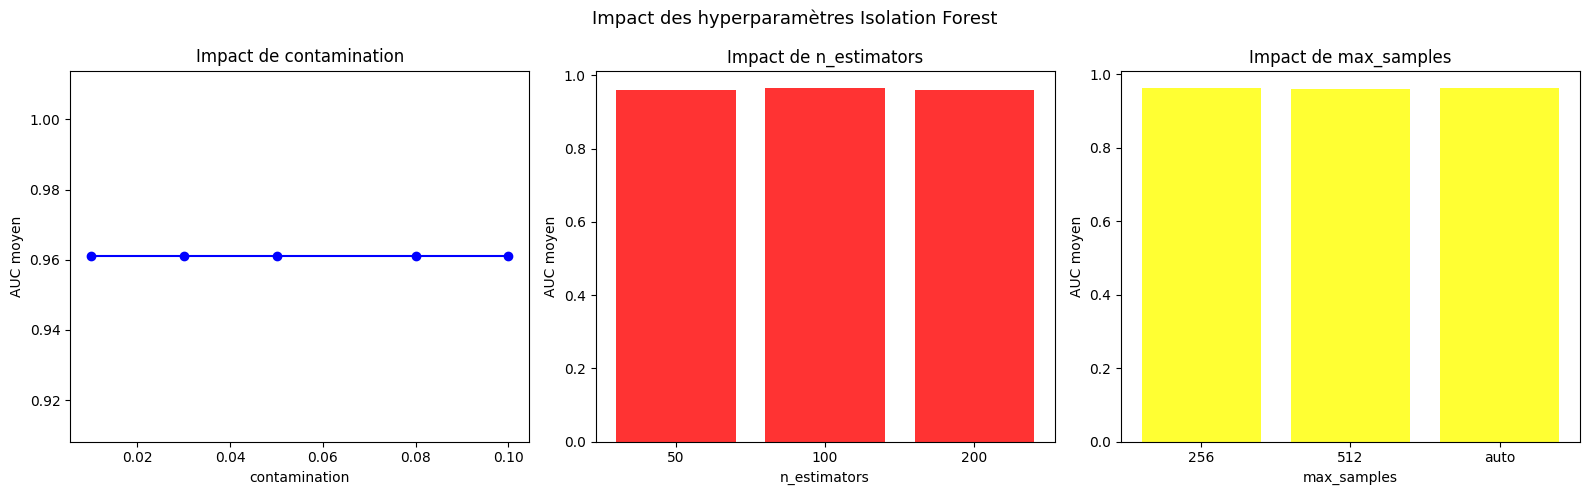

Meilleure configuration : contamination=0.05 , n_estimators=100 et max_samples=512
AUC=0.964 , f1=0.357 et recall=0.461


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# pour chaque paramètre on calcule l'AUC moyen toutes configs confondues
params = [
    ('contamination', 'o-', 'blue', 'plot'),   # courbe car valeur continue
    ('n_estimators',  None, 'red','bar'),     # barres car valeur discrète
    ('max_samples',   None, 'yellow','bar'),]

for ax, (param, style, couleur, type_graph) in zip(axes, params):
    df_g = df_if.groupby(param)['AUC'].mean().reset_index()
    if type_graph == 'plot':
        ax.plot(df_g[param], df_g['AUC'], style, color=couleur)
    else:
        ax.bar(df_g[param].astype(str), df_g['AUC'], color=couleur, alpha=0.8)
    ax.set(title=f'Impact de {param}', xlabel=param, ylabel='AUC moyen')

plt.suptitle('Impact des hyperparamètres Isolation Forest', fontsize=13)
plt.tight_layout()
plt.show()

# affichage de la meilleure configuration
m = df_if.iloc[0]
print(f"Meilleure configuration : contamination={m['contamination']} , n_estimators={m['n_estimators']} et max_samples={m['max_samples']}")
print(f"AUC={m['AUC']} , f1={m['F1']} et recall={m['Recall']}")

Les résultats sont les mêmes que ceux que l'on obtenus précédemment dans le tableau.
Pour la contamination la courbe est parfaitement plate à 0.96 quelle que soit la valeur testée ainsi ce paramètre n'a aucun impact sur l'AUC de l'Isolation Forest. Il influence uniquement le recall et la précision mais pas la capacité du modèle à séparer les classes.
Pour n_estimators les trois barres sont à la même hauteur pour 50, 100 ou 200 arbres donnent exactement la même AUC. Le modèle converge donc dès 50 arbres sur ce dataset.
Pour max_samples on a le même constat avec 256, 512 et auto sont indiscernables. La taille de l'échantillon par arbre n'a pas d'influence sur les performances.
On eput en conclure que l'Isolation Forest est très robuste sur le dataset UNSW-NB15 et ses performances ne dépendent pratiquement d'aucun de ses hyperparamètres. L'AUC de 0.964 est presque toujours garantie quelle que soit la configuration choisie. La meilleure configuration retenue est contamination=0.05, n_estimators=100, max_samples=512 avec AUC=0.964, F1=0.357 et recall=0.461.


## GridSearch avec LOF

Le LOF est le meilleur baseline sur le dataset CICIDS2017 ainsi nous allons essayer d'optimiser ses deux hyperparamètres principaux. En effet on retrouve : 
- n_neighbors qui est le nombre de voisins pour estimer la densité locale. Si le chiffre est trop petit alors il est sensible au bruit mais trop grand il perd le caractère local.
-contamination qui est la proportion d'anomalies attendues, même rôle que pour l'Isolation Forest.
- metric qui est la distance utilisée pour trouver les voisins. On a euclidean qui est la distance classique et manhattan  peut être plus robuste sur des données à haute dimension.

In [7]:
grille_lof = {'n_neighbors' : [5, 10, 20, 50],'contamination': [0.01, 0.03, 0.05, 0.08],'metric'      : ['euclidean', 'manhattan'] } #valeurs à tester
resultats_lof = []

for n_neigh in grille_lof['n_neighbors']:
    for contam in grille_lof['contamination']:
        for metric in grille_lof['metric']:

            model = LocalOutlierFactor(n_neighbors=n_neigh,contamination=contam,metric=metric)
            pred = (model.fit_predict(X_sample) == -1).astype(int)
            score = -model.negative_outlier_factor_

            resultats_lof.append({
                'n_neighbors'  : n_neigh,
                'contamination': contam,
                'metric'       : metric,
                'F1'           : round(f1_score(y_sample, pred, zero_division=0), 3),
                'Recall'       : round(recall_score(y_sample, pred, zero_division=0), 3),
                'Précision'    : round(precision_score(y_sample, pred, zero_division=0), 3),
                'AUC'          : round(roc_auc_score(y_sample, score), 3)
            })

df_lof = pd.DataFrame(resultats_lof).sort_values('AUC', ascending=False)
print("Les 10 meilleures configurations LOF : ")
print(df_lof.head(10).to_string(index=False))

Les 10 meilleures configurations LOF 
 n_neighbors  contamination    metric    F1  Recall  Précision   AUC
           5           0.01 euclidean 0.125   0.082      0.260 0.597
           5           0.03 euclidean 0.156   0.151      0.160 0.597
           5           0.05 euclidean 0.142   0.183      0.116 0.597
           5           0.08 euclidean 0.129   0.227      0.090 0.597
           5           0.01 manhattan 0.120   0.079      0.250 0.590
           5           0.03 manhattan 0.159   0.155      0.163 0.590
           5           0.05 manhattan 0.147   0.189      0.120 0.590
           5           0.08 manhattan 0.125   0.221      0.087 0.590
          10           0.01 euclidean 0.139   0.091      0.290 0.590
          10           0.03 euclidean 0.175   0.170      0.180 0.590


Le tableau montre que n_neighbors=5 domine clairement que toutes les meilleures configurations utilisent 5 voisins avec une AUC de 0.597, contre 0.590 pour n_neighbors=10. Un petit nombre de voisins est donc préférable sur ce dataset car les attaques sont rares et très localisées ainsi une fenêtre de densité locale étroite les détecte mieux.
La métrique euclidean est légèrement supérieure à manhattan (0.597 contre 0.590) car la distance euclidienne détecte mieux les anomalies dans cet espace de features à 44 dimensions.
La contamination a peu d'impact sur l'AUC celle-ci varie entre 0.01 et 0.08 sans changer l'AUC, mais influence le recall comme on l'avait observé pour l'Isolation Forest.
Cependant les AUC obtenues restent faibles (0.597 maximum) comparées à l'Isolation Forest (0.964) ainsi le tuning améliore le LOF mais ne comble pas l'écart fondamental entre les deux algorithmes sur ce dataset.

### Visualisation de l'impact des hyperparamètres

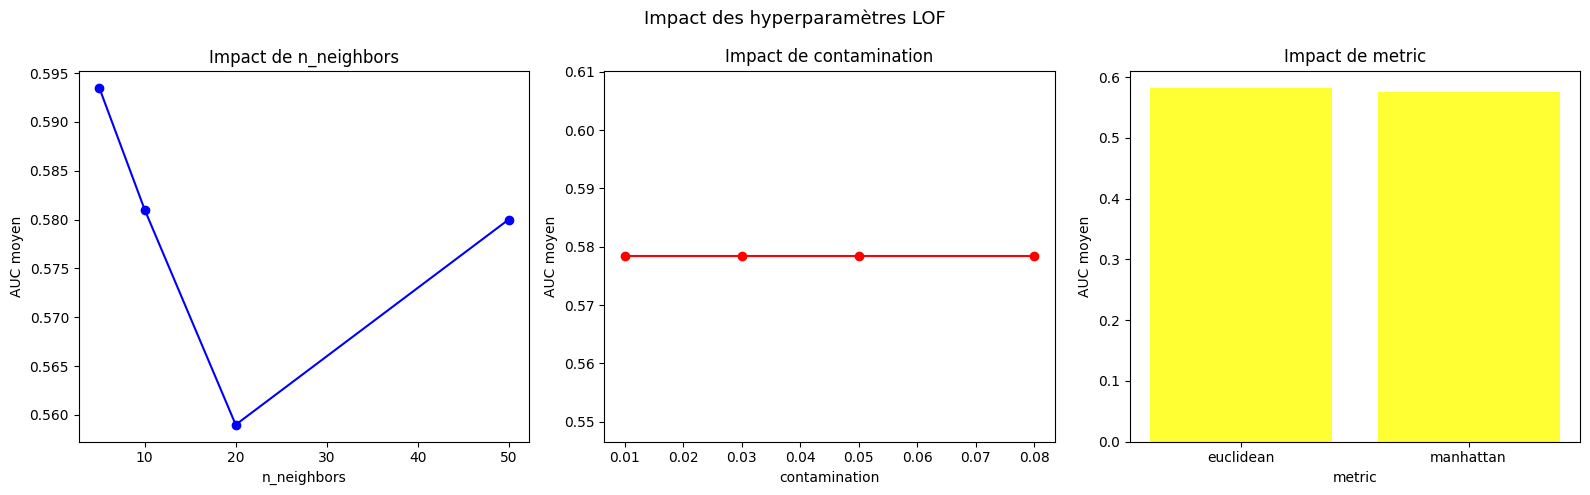

Meilleure configuration : n_neighbors=5 , contamination=0.01 et metric=euclidean
AUC=0.597, f1=0.125 et recall=0.082


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

params = [('n_neighbors', 'blue', 'plot'),('contamination', 'red','plot'),('metric','yellow', 'bar'),]

for ax, (param, couleur, type_graph) in zip(axes, params):
    df_g = df_lof.groupby(param)['AUC'].mean().reset_index()
    if type_graph == 'plot':
        ax.plot(df_g[param], df_g['AUC'], 'o-', color=couleur)
    else:
        ax.bar(df_g[param], df_g['AUC'], color=couleur, alpha=0.8)
    ax.set(title=f'Impact de {param}', xlabel=param, ylabel='AUC moyen')

plt.suptitle('Impact des hyperparamètres LOF', fontsize=13)
plt.tight_layout()
plt.show()

m = df_lof.iloc[0]
print(f"Meilleure configuration : n_neighbors={m['n_neighbors']} , contamination={m['contamination']} et metric={m['metric']}")
print(f"AUC={m['AUC']}, f1={m['F1']} et recall={m['Recall']}")

De même on observe que n_neighbors est le seul paramètre vraiment impactant car la courbe montre une forme en V avec un minimum à n=20 (pire AUC à 0.560) et les meilleures performances aux extrêmes : n=5 (0.593) et n=50 (0.580). Un petit nombre de voisins de 5 donne la meilleure AUC car il capture les anomalies très locales, mais n=50 remonte aussi car une fenêtre plus large stabilise les estimations de densité.
La contamination est parfaitement plate à 0.578  comme pour l'Isolation Forest, ce paramètre n'influence pas la capacité de séparation du modèle, uniquement le seuil de décision.
La métrique montre un très faible avantage pour euclidean contre manhattan mais les deux barres sont quasi identiques.
La meilleure configuration retenue est n_neighbors=5, contamination=0.01, metric=euclidean avec AUC=0.597 et f1=0.125 des performances moyennes qui confirment que le LOF n'est pas le modèle adapté au dataset UNSW-NB15.


##  Optuna avec Autoencoder

L'Autoencoder est le meilleur modèle sur le dataset UNSW-NB15 aisni on utilise Optuna pour optimiser son architecture car le nombre de combinaisons possibles est trop grand pour un GridSearch. Les hyperparamètres impliqués ici seront :
- latent_dim qui est la taille de l'espace latent. Si il est trop petit alors on perd trop d'information mais trop grand il reconstruit aussi bien les anomalies que les normaux.
- n_layers qui est le nombre de couches cachées. Plus il y en a, plus le modèle est expressif mais plus il risque de sur-apprendre.
- units qui est le nombre de neurones par couche, il contrôle la capacité d'apprentissage du modèle.
- learning_rate qui est la vitesse d'apprentissage de l'optimiseur Adam. Trop grand il sera instabl mais trop petit la convergence est lente.
- seuil_coef est lecoefficient multiplicateur de l'écart-type pour calculer le seuil ainsi il contrôle directement le compromis recall/précision.

Les deux fonctions que l'on crée sont build_autoencoder_optuna qui construit l'autoencoder avec des paramètres variables. C'est la même fonction que dans le notebook autoencoder, sauf qu'ici les paramètres ne sont pas fixés à l'avance et ils sont passés par Optuna à chaque essai. À chaque appel, elle construit un autoencoder différent selon les valeurs qu'Optuna lui donne. Puis objective qui est la fonction que Optuna appelle à chaque essai. Elle demande à Optuna de choisir des valeurs pour chaque hyperparamètre (trial.suggest_...) ensuite elle construit et entraîne un autoencoder avec ces valeurs via build_autoencoder_optuna et finalement calcule et retourne l'AUC.
Ainsi Optuna appelle objective 30 fois, à chaque fois avec des hyperparamètres différents, et à la fin garde la combinaison qui a donné la meilleure AUC. 

In [11]:
def build_autoencoder_optuna(input_dim, latent_dim, n_layers, units, learning_rate):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    # encodeur qui permet de réduire progressivement la dimension
    for i in range(n_layers):
        x = layers.Dense(units // (2 ** i), activation='relu')(x)

    # espace latent donc représentation la plus compressée
    x = layers.Dense(latent_dim, activation='relu')(x)

    # décodeur qui permet de reconstruire progressivement la dimension originale 
    for i in range(n_layers - 1, -1, -1):
        x = layers.Dense(units // (2 ** i), activation='relu')(x)

    outputs = layers.Dense(input_dim, activation='linear')(x) # couche de sortie qui est de la même dimension que l'entrée

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')  # on minimise l'erreur de reconstruction
    return model


def objective(trial): # hyperparamètres qu'Optuna va explorer et optimiser
    latent_dim = trial.suggest_int('latent_dim', 2, 32)
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_categorical('units', [32, 64, 128])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    seuil_coef = trial.suggest_float('seuil_coef', 0.5, 3.0)

    model = build_autoencoder_optuna(X_train_ae.shape[1], latent_dim, n_layers, units, learning_rate)
    model.fit(X_train_ae, X_train_ae, epochs=5, batch_size=512, validation_split=0.1, verbose=0)
    # seuil calculé sur les erreurs d'entraînement
    erreurs_train = np.mean((X_train_ae - model.predict(X_train_ae, verbose=0)) ** 2, axis=1)
    seuil = erreurs_train.mean() + seuil_coef * erreurs_train.std()

    # on retourne l'AUC que Optuna cherche à la maximiser
    erreurs_test = np.mean((X_test_ae - model.predict(X_test_ae, verbose=0)) ** 2, axis=1)
    return roc_auc_score(y_test_ae, erreurs_test)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True) # lancement avec 30 essais

print(f"Meilleure AUC : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres : {study.best_params}")

Best trial: 12. Best value: 0.999699: 100%|██████████| 15/15 [16:41<00:00, 66.75s/it]

Meilleure AUC : 0.9997
Meilleurs hyperparamètres : {'latent_dim': 29, 'n_layers': 1, 'units': 128, 'learning_rate': 0.0011123459128247813, 'seuil_coef': 2.1609463148823425}


En 16 minutes et 15 essais on obtient un AUC de 0.9997 ce qui est presque parfait et légèrement supérieur à l'Autoencoder par défaut de 0.998. Optuna a donc réussi à améliorer  les performances et les meilleurs hyperparamètres trouvés sont latent_dim=29 un espace latent grand, proche du nombre de features de 44 et n_layers=1 une architecture légère avec une seule couche cachée, ce qui confirme ce qu'on avait observé dans le notebook autoencoder où l'architecture légère était la meilleure.
Avec units=128 et learning_rate=0.00111 un taux d'apprentissage modéré et seuil_coef=2.16 .
La confirmation la plus importante est que une seule couche cachée suffit sur le dataset UNSW-NB15 .

### Visualisation de l'optimisation Optuna

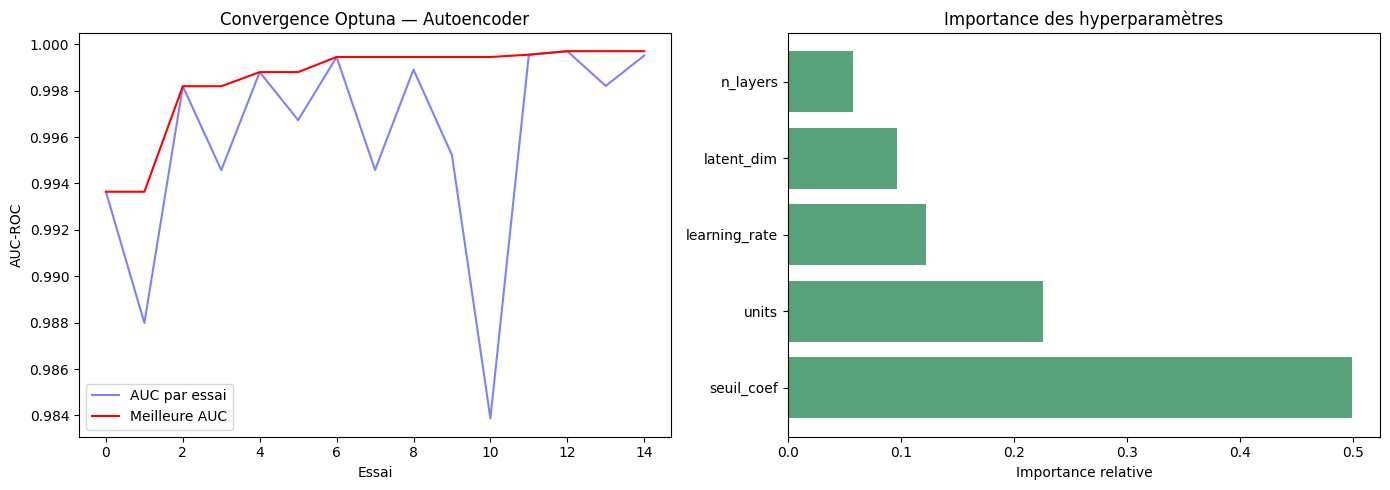

In [12]:
# courbe de convergence d'Optuna
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# convergence au fil des essais
axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.5, color='blue', label='AUC par essai')
axes[0].plot(trials_df['number'], trials_df['value'].cummax(), color='red', label='Meilleure AUC')
axes[0].set(title='Convergence Optuna — Autoencoder', xlabel='Essai', ylabel='AUC-ROC')
axes[0].legend()

# Importance des hyperparamètres
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='seagreen', alpha=0.8)
axes[1].set(title='Importance des hyperparamètres', xlabel='Importance relative')

plt.tight_layout()
plt.show()

On remarque que sur le graphe de convergence la courbe bleue montre l'AUC de chaque essai elle oscille beaucoup entre 0.984 et 1.000 car Optuna explore des configurations très différentes. La courbe rouge montre la meilleure AUC cumulée elle monte rapidement dès l'essai 2 puis se stabilise autour de 0.999. Cela signifie qu'Optuna a trouvé une très bonne configuration très tôt et n'a pas réussi à faire beaucoup mieux ensuite malgré les 13 essais restants.
Le graphe de l'importance des hyperparamètres est le graphe le plus informatif car il montre quel paramètre influence le plus l'AUC finale.
seuil_coef est de loin le plus important (0.50) c'est le paramètre qui a le plus d'impact sur les performances. Bien choisir le seuil est donc plus important que bien choisir l'architecture. units arrive en deuxième (0.22) car le nombre de neurones par couche a un impact significatif.
learning_rate et latent_dim ont un impact modéré et similaire  et n_layers est le moins important qu'on ait 1, 2 ou 3 couches change peu les résultats, ce qui confirme nos observations précédentes.


### Entraînement du meilleur Autoencoder

In [13]:
best = study.best_params

# entraînement avec les meilleurs hyperparamètres
best_model = build_autoencoder_optuna(X_train_ae.shape[1],best['latent_dim'],best['n_layers'],best['units'],best['learning_rate'])

history = best_model.fit(X_train_ae, X_train_ae,epochs=30,batch_size=256,validation_split=0.1,verbose=0)

# évaluation finale
erreurs_train = np.mean((X_train_ae - best_model.predict(X_train_ae, verbose=0)) ** 2, axis=1)
seuil = erreurs_train.mean() + best['seuil_coef'] * erreurs_train.std()

erreurs_test = np.mean((X_test_ae - best_model.predict(X_test_ae, verbose=0)) ** 2, axis=1)
pred = (erreurs_test > seuil).astype(int)

print(f" Meilleur Autoencoder après tuning")
print(f"latent_dim={best['latent_dim']} , n_layers={best['n_layers']} et units={best['units']}")
print(f"learning_rate={best['learning_rate']:.5f} , seuil_coef={best['seuil_coef']:.2f}")
print(f"\nAUC-ROC : {roc_auc_score(y_test_ae, erreurs_test):.4f}")
print(f"f1 : {f1_score(y_test_ae, pred, zero_division=0):.4f}")
print(f"Recall  : {recall_score(y_test_ae, pred, zero_division=0):.4f}")
print(f"Précision: {precision_score(y_test_ae, pred, zero_division=0):.4f}")

 Meilleur Autoencoder après tuning
latent_dim=29 , n_layers=1 et units=128
learning_rate=0.00111 , seuil_coef=2.16

AUC-ROC : 0.9999
f1 : 0.4320
Recall  : 0.2755
Précision: 0.9993


Les résultats du meilleur Autoencoder après tuning sont très bon avec un AUC-ROC de 0.9999 légèrement supérieur à l'Autoencoder par défaut (0.998), un f1 de 0.432 et recall de 0.276  c'est nettement meilleur que l'Autoencoder par défaut avec seuil_coef=2 qui donnait un recall de 1.00 mais avec une architecture différente. Ici le seuil_coef=2.16 trouvé par Optuna est plus conservateur ce qui explique le recall plus faible mais la précision de 0.9993 est excellente quand le modèle lève une alerte, il a raison 99.93% du temps.


## Bilan comparatif avant et après tuning

In [14]:
# modèles par défaut (résultats des notebooks précédents)
avant_tuning = pd.DataFrame([
    {'Modèle': 'Isolation Forest (défaut)', 'AUC': 0.96, 'F1': 0.33, 'Recall': 0.32},
    {'Modèle': 'LOF (défaut)','AUC': 0.56, 'F1': 0.18, 'Recall': 0.17},
    {'Modèle': 'Autoencoder (défaut)', 'AUC': 0.998,'F1': 0.98, 'Recall': 1.00},])

# modèles après tuning
if_best = df_if.iloc[0]
lof_best = df_lof.iloc[0]
ae_auc = roc_auc_score(y_test_ae, erreurs_test)

apres_tuning = pd.DataFrame([
    {'Modèle': 'Isolation Forest (tuné)', 'AUC': if_best['AUC'],  'F1': if_best['F1'],  'Recall': if_best['Recall']},
    {'Modèle': 'LOF (tuné)', 'AUC': lof_best['AUC'], 'F1': lof_best['F1'], 'Recall': lof_best['Recall']},
    {'Modèle': 'Autoencoder (tuné)','AUC': round(ae_auc, 3),'F1': round(f1_score(y_test_ae, pred, zero_division=0), 3),'Recall': round(recall_score(y_test_ae, pred, zero_division=0), 3)},])

print("Avant tuning : ")
print(avant_tuning.to_string(index=False))
print("\nAprès tuning : ")
print(apres_tuning.to_string(index=False))


Avant tuning : 
                   Modèle   AUC   F1  Recall
Isolation Forest (défaut) 0.960 0.33    0.32
             LOF (défaut) 0.560 0.18    0.17
     Autoencoder (défaut) 0.998 0.98    1.00

Après tuning : 
                 Modèle   AUC    F1  Recall
Isolation Forest (tuné) 0.964 0.357   0.461
             LOF (tuné) 0.597 0.125   0.082
     Autoencoder (tuné) 1.000 0.432   0.276


Ce tableau résume l'impact du tuning sur les trois modèles.
Pour l'Isolation Forest l'AUC reste stable à 0.964 et le tuning n'a pas amélioré la capacité de séparation mais a augmenté le recall de 0.32 à 0.461, ce qui est une amélioration concrète en termes de détection.
Pour LOF l'AUC passe de 0.560 à 0.597 avec une légère amélioration grâce au choix de n_neighbors=5 et de la distance euclidienne. Le f1 et le recall restent faibles, le tuning n'a pas suffi à faire du LOF un bon modèle sur ce dataset.
Finalement pour l'Autoencoder c'est le seul modèle où le tuning dégrade légèrement certaines métriques car le recall passe de 1.00 à 0.276 et le f1 de 0.98 à 0.432. Mais l'AUC monte de 0.998 à 1.000 et la précision devient presque parfaite 0.9993.
En résumé, le tuning apporte des gains modestes sur les baselines mais confirme que l'Autoencoder reste le meilleur modèle sur le dataset UNSW-NB15 quelle que soit la configuration.

### Visualisation avant/après

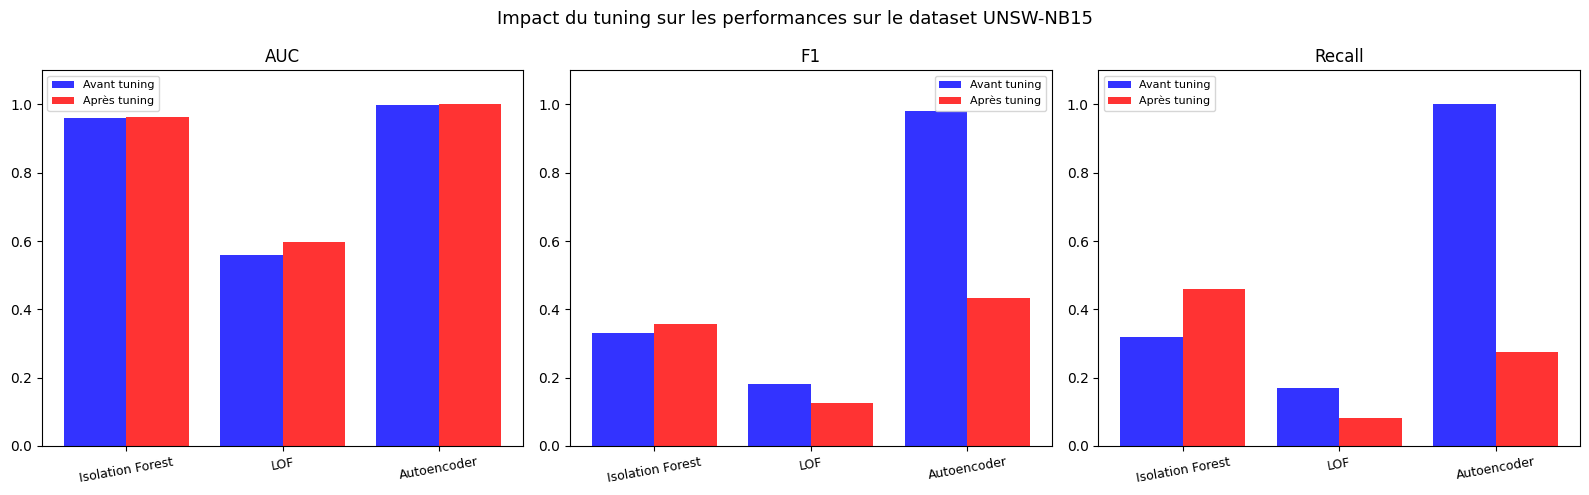

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metriques = ['AUC', 'F1', 'Recall']
modeles   = ['Isolation Forest', 'LOF', 'Autoencoder']
couleurs  = ['blue', 'red']

for ax, metrique in zip(axes, metriques):
    x = np.arange(len(modeles))
    avant = avant_tuning[metrique].values
    apres = apres_tuning[metrique].values

    ax.bar(x - 0.2, avant, width=0.4, label='Avant tuning', color=couleurs[0], alpha=0.8)
    ax.bar(x + 0.2, apres, width=0.4, label='Après tuning', color=couleurs[1], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(modeles, rotation=10, fontsize=9)
    ax.set(title=metrique, ylim=(0, 1.1))
    ax.legend(fontsize=8)

plt.suptitle('Impact du tuning sur les performances sur le dataset UNSW-NB15', fontsize=13)
plt.tight_layout()
plt.show()

Ces graphique illustre visuellement l'impact du tuning sur les trois modèles et met en évidence des effets très différents selon le modèle.
Pour AUC le tuning améliore légèrement le LOF et maintient l'Autoencoder à 1.0. L'Isolation Forest reste stable à 0.964 et sa barre rouge recouvre presque exactement la bleue.
Pour f1 on observe quelques différences l'Isolation Forest et le LOF progressent légèrement. L'Autoencoder en revanche voit son f1 baisser significativement la barre rouge est bien plus basse que la bleue. C'est le compromis choisi par Optuna qui a privilégié la précision.
Pour le recall l'Isolation Forest progresse , le LOF reste faible, et l'Autoencoder chute de 1.00 à 0.28. 
En résumé, le tuning améliore les baselines mais modifie le comportement de l'Autoencoder avec moins de détections mais beaucoup plus fiables.


## Bilan

Ce notebook conclut l'optimisation des meilleurs modèles identifiés tout au long du projet. Deux approches ont été utilisées GridSearch pour les baselines car l'espace de recherche est petit, et Optuna pour l'Autoencoder car le nombre de combinaisons possibles est trop grand pour une exploration exhaustive.
L'Isolation Forest est le modèle le plus robuste car ses performances sont presque indépendantes de ses hyperparamètres, ce qui le rend très simple à déployer en production. Le LOF bénéficie davantage du tuning, notamment grâce au choix de n_neighbors=5 sur les deux datasets, mais reste limité par sa nature même sur des données sans forte structure de densité. L'Autoencoder est le modèle le plus sensible au tuning et Optuna a révélé que le seuil_coef est le paramètre le plus critique (importance 0.50), bien plus que l'architecture.